# Ayan's `XGBDT SHAP` Values Analysis

## Purpose: 

{TODO}

In [ ]:
%load_ext autoreload 
%autoreload 2
    
import importlib
    
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from IPython.display import Image
from IPython.display import display

import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)


import polars as pl 
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(100000)
_=pl.Config.set_tbl_width_chars(10000)

import matplotlib.pyplot as plt 
import seaborn as sns 

AyanXgbdtAnalyzer = getattr(
    importlib.import_module("1_Ayan_XGBDT_Analyzer"), 
    "AyanXgbdtAnalyzer"
)

CellLineCompareTool = getattr(
    importlib.import_module("1_Ayan_XGBDT_Analyzer"), 
    "CellLineCompareTool"
)



## Literals

In [ ]:
cell_lines = ["K562", "HepG2"]
best_performing_distance_threshold=100

## Load Analyzer Class (per Cell Line)

In [ ]:
analyzers = {}

for cell_line in cell_lines:
    
    analyzers[cell_line] = AyanXgbdtAnalyzer(
        cell_line = cell_line, 
        distance_threshold = best_performing_distance_threshold
    )

# **CTRL-Only Binding Analyses**

## Load `CTRL`-only `binding data` to understand **UNIVARIATE** associations between `RBPs`/features and `PSI`

In [ ]:
for cell_line in analyzers:
    analyzers[cell_line].load_ctrl_only_binding_data()

## What does the distribution of PSI values look like?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_psi_distribution()

## Is there any relationship between chromosome and PSI values?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].compare_chromosome_vs_psi()

#### Duplication issue!!!

The issue is that when looking at binding, etc. there is duplication. 
For example, the skipping exon could be an upstream or downstream exon for the neighboring exon's SE event. 

Hence, let's see how many times each "main exon" is either an upstream or downstream exon. 

In [ ]:
for cell_line in analyzers: 

    cell_line 
    
    counts = analyzers[cell_line].plot_upstream_and_downstream_exon_duplication()

    counts["Counts"].describe()

## `Chi-Square Test` **FOR EACH** feature where the categories are "Binding Present/Absent" and "PSI threshold group"

In [ ]:
for cell_line in analyzers: 

    analyzers[cell_line].run_parallel_feature_chi_square_tests().head()

In [ ]:
analyzers[cell_line].feature_chi_square_contingency_tables["AQR_center_right"]

In [ ]:
for cell_line in analyzers: 
    plot_df, increasing_features, decreasing_features = analyzers[cell_line].plot_chi_square_bound_proportion_lines()
    "plot df"
    plot_df.head()
    "increasing features"
    increasing_features
    "decreasing features"
    decreasing_features

In [ ]:
for cell_line in analyzers:
    
    analyzers[cell_line].plot_feature_chi_square_statistics()

# **GLOBAL `SHAP` Analyses** 

## Load `SHAP` Datasets

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].load_SHAP_data()

## How similar are the `predicted` vs `actual` `PSI` values for this model?


In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].predicted_vs_actual_PSI_model()

## What are the `Global SHAP` values like for our features and how does that correlate with: 
* Total amount of binding?
* Positional preferences of RBPs?


In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_global_SHAP_vs_binding_plots()

## What are the above plots like if we subset to different PSI thresholds?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_partition_global_SHAP_vs_binding_plots()

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_partition_percent_events_bound()
    analyzers[cell_line].plot_partition_global_SHAP()

## Which features have Global SHAPs that monotonically increase or decrease with `PSI` bin?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_global_SHAP_partition_monotonicity()

## How does the rank of a feature's `Global SHAP` correspond to the rank of that same feature's `Chi-Square Statistic`?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_rank_global_SHAP_vs_rank_chi_square()

## For each feature, how does `Chi Square`, `ANOVA`, `Kruskal Wallis`, and `Global SHAP` compare?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_kruskal_anova_chi_SHAP().head()

# **LOCAL `SHAP` Analyses** 

## For each feature, are the local SHAP values consistently in one direction (positive, negative, mixed, zero, empty)?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_local_SHAP_summary()

## Does the distribution of local `SHAP` values significantly differ between the 3 `PSI` threshold groups?

NOTE: the 3 groups are: 
* `PSI` < 0.1
* `PSI` >= 0.1 & `PSI` <= 0.9
* `PSI` > 0.9

#### `Kruskal-Wallis` (Non-Parametric)

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].run_parallel_feature_specific_kruskal_wallis()

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_kruskal_wallis_statistics().head()

#### `ANOVA` (Parametric)

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].run_parallel_feature_specific_ANOVA()

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_anova_statistics().head()

## For a given feature, what is the distribution of the `local SHAP` values when split by `test, train, validate`?

In [ ]:
# for cell_line in analyzers: 
#     for feature in analyzers[cell_line].shap_columns: 
#         ! sbatch --account=platiglab --partition=standard -N 1 -n 4 --mem=10GB --output=./SLURM_logs/{cell_line}-{feature}.out --error=./SLURM_logs/{cell_line}-{feature}.err --wrap="python 1_Ayan_XGBDT_Analyzer.py --cell_line {cell_line} --distance 100 --parallel-task feature_local_shap --feature {feature}"

## What does the distribution of local SHAP values look like per RBP?

In [ ]:
# for cell_line in analyzers: 
#     unique_rbps = sorted(list(set(analyzers[cell_line].get_rbp_and_position(col)[0] for col in analyzers[cell_line].shap_columns)))

#     for rbp in unique_rbps: 
#         ! sbatch --account=platiglab --partition=standard -N 1 -n 2 --mem=30GB --output=./SLURM_logs/{cell_line}-{rbp}.out --error=./SLURM_logs/{cell_line}-{rbp}.err --wrap="python 1_Ayan_XGBDT_Analyzer.py --cell_line {cell_line} --distance 100 --parallel-task rbp_local_shap --rbp {rbp}"

## What do the SHAP values look like for the SRSF proteins and HNRNP proteins which are known to be activators (exon inclusion) and repressors (exon skipping)?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_srsf_and_hnrnp_local_SHAP_features()

## Do some of these metrics have similarities across cell lines (using `RBPs` where both have `eCLIP`)?

In [ ]:
# compare_sets = []
# for cell_line in data_dict: 
#     compare_sets.append(
#         {column.split("_")[0] for column in data_dict[cell_line].columns if column.endswith("_left") or column.endswith("_right")}
#     )

# common_rbps = sorted(compare_sets[0].intersection(compare_sets[1]))
# print(common_rbps)

In [ ]:
# plot_definitions = {
#     "Global SHAP": {
#         "K562": global_shap["K562"],
#         "HepG2": global_shap["HepG2"],
#     }, 
#     "Per-RBP % Normalized Global SHAP": {
#         "K562": global_shap["K562"].apply(lambda x: (x / x.sum())*100, axis=0),
#         "HepG2": global_shap["HepG2"].apply(lambda x: (x / x.sum())*100, axis=0)  
#     },
#     "% of Sample-Specific Events Bound": {
#         "K562": total_binding_percentage["K562"], 
#         "HepG2": total_binding_percentage["HepG2"]
#     }, 
#     "% RBP Binding At Specific Position": {
#         "K562": positional_preference["K562"], 
#         "HepG2": positional_preference["HepG2"]
#     }
    
# }

# for key in plot_definitions: 
#     for sub_key in plot_definitions[key]: 
        
#         tmp_df = plot_definitions[key][sub_key]
        
#         plot_definitions[key][sub_key] = tmp_df[[column for column in tmp_df.columns.to_list() if column in common_rbps]]


# compare_cell_line_heatmaps(meta_plotting_df = plot_definitions)
        

## How do some of these metrics look like when comparing specific "positive control" known `splice factors` vs. "irrelevant" `RBPs`?

## Is there a relationship between specific features and local `SHAP` values?

In [ ]:
for cell_line in cell_lines: 

    tmp_df = data_dict[cell_line]

    plt.figure(dpi=200, figsize=(100, 5))
    
    plt.boxplot(
        [tmp_df[col].to_list() for column in tmp_df.columns if "RBFOX2" in column and (column.endswith("_left") or column.endswith("_right"))], 
        tick_labels = [column for column in tmp_df.columns if "RBFOX2" in column and (column.endswith("_left") or column.endswith("_right"))]
    )

    plt.show()

# **Comparison Between Cell Lines**

## How do the Global SHAP values compare between cell lines?

In [ ]:
cell_line_comparer = CellLineCompareTool(
    K562 = analyzers["K562"], 
    HepG2 = analyzers["HepG2"]
)

In [ ]:
cell_line_comparer.plot_global_SHAP_comparison()

In [ ]:
cell_line_comparer.plot_chi_square_comparison().head(n=20)

## Despite larger distance thresholds having lower `R^2` performance, do they do better at predicting non-0/1 `PSI`? 

In [ ]:

# for cell_line in cell_lines: 
    
#     for threshold in distance_thresholds: 
#         f"{cell_line} {threshold}"
        
#         files = [ file for file in shap_files if f"{cell_line}-{threshold}-" in file and "-train-" not in file ]
#         assert len(files)==2, [file.split("/")[-1] for file in files]        
        

#         plt.figure(dpi=100, figsize=(10,10))
        
        
#         df = [pd.read_csv(file, sep=",", usecols=[actual_psi_column_name, predicted_psi_column_name]) for file in files if "-train-" not in file]
        
#         df = pd.concat(df)
        
# #         sns.scatterplot(
# #             df, 
# #             x="target", 
# #             y="psi_hat", 
# #             size=0.00000000000001
        
# #         )

#         plt.hist2d(
        
#             df["target"].to_list(), 
#             df["psi_hat"].to_list(), 
#             bins=10
            
#         )
          
#         plt.show()

# `RBP PPIs`

## How do `XGBoost` and `Linear Regression` compare to each other (performance-wise) when only looking at events where there are RBP PPIs?


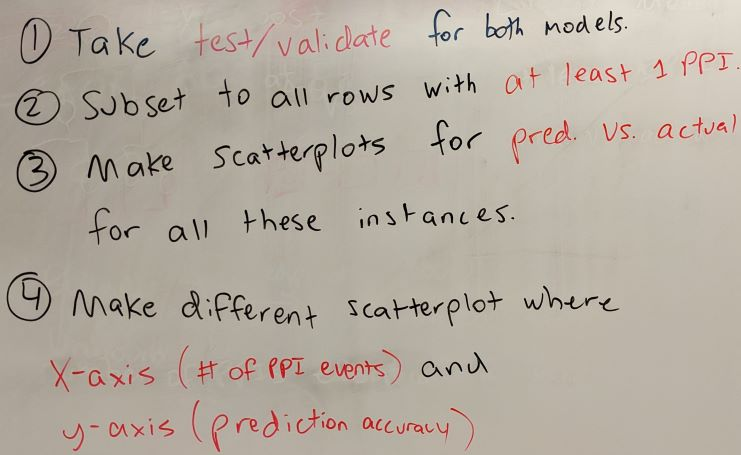

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].compare_rbp_ppi_performance_xgboost_vs_linear_model()

## Do `RBP PPI pairs` have similar `SHAP` in places where they bind together vs. don’t bind?

In [ ]:

if os.path.exists(rbp_comparisons_file):
    with open(rbp_comparisons_file) as file: 
        comparison_rbps = json.load(file)

else: 

    comparison_rbps = {}
    
    for cell_line in data_dict: 
        comparison_rbps[cell_line] = sorted(retrieve_rbp_comparison_cols(data_dict[cell_line], rbp_ppi, uniprot_id_mapping))

    with open(rbp_comparisons_file, 'w') as out_file: 
        json.dump(comparison_rbps, out_file, indent=4)

In [ ]:
print(comparison_rbps)

In [ ]:
# for cell_line in comparison_rbps: 
#     for ppi_pair in comparison_rbps[cell_line]: 

#         ppi_pair = sorted(ppi_pair)
#         slurm_output_string = f"{cell_line}_{ppi_pair[0]}_{ppi_pair[1]}"

#         ! sbatch --account="platiglab" --partition=standard -N 1 -n 1 --mem=20GB --output={slurm_output_string}.out --error={slurm_output_string}.err --wrap="python3 1_plot_interacting_RBP_SHAP_values.py --cell_line {cell_line} --ppi_rbp1 {ppi_pair[0]} --ppi_rbp2 {ppi_pair[1]}"   

In [ ]:
# ! find . -type f -empty -exec rm -f '{}' \; 
# ! ls 